### Complete dataset

In [2]:
from google.auth.transport.requests import Request
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

import os.path

SCOPES = ['https://www.googleapis.com/auth/gmail.modify']

def get_token():
    creds = None
    token = None
    if os.path.exists("gcp/token.json"):
        creds = Credentials.from_authorized_user_file("gcp/token.json", SCOPES)
        print("Token loaded from gcp/token.json")
        
    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            flow = InstalledAppFlow.from_client_secrets_file(
                "gcp/credentials.json", SCOPES
            )
            creds = flow.run_local_server(port=0)
            # Save the credentials for the next run
        with open("gcp/token.json", "w") as token:
            token.write(creds.to_json())
            print("Token saved to gcp/token.json")
    
    return token

get_token()

service = build("gmail", "v1", credentials=Credentials.from_authorized_user_file("gcp/token.json", SCOPES))

Token loaded from gcp/token.json


In [3]:
# body_text

import re
from bs4 import BeautifulSoup

def clean_email_body(raw_content):
    """
    Removes HTML, CSS, hidden characters, shortens URLs.
    """
    if not raw_content:
        return ""

    # cause html tags and css/style blocks
    soup = BeautifulSoup(raw_content, "html.parser")
    for element in soup(["style", "script", "link"]):
        element.decompose()

    text = soup.get_text(separator=' ')
    text = text.replace('\u200c', '').replace('\xa0', ' ')

    # url handling
    def url_cleaner(match):
        url = match.group(0)
        if len(url) > 60:
            return "[URL]"
        return url

    # re.sub(pattern, repl, string)
    # r'https?://\S+' - either http or https followed by characters until space.
    # matched text is passed to url_cleaner
    text = re.sub(r'https?://\S+', url_cleaner, text)

    # replaces multiple newlines, spaces with a single one
    text = re.sub(r'\n\s*\n', '\n', text)
    text = re.sub(r' +', ' ', text)
    text = text.strip()

    return text

In [6]:
import json
import base64

how_much = 10
filename = f"exported_emails_{how_much}.jsonl"

try:
    response = service.users().messages().list(
        userId='me', 
        maxResults=how_much
    ).execute()    
    messages = response.get('messages', [])
    if not messages:
        print("No messages found in the mailbox.")
    print(f"Found {len(messages)} messages. Processing...")
    with open(filename, 'w', encoding='utf-8') as jsonl_file:
        for msg_item in messages:
            message_id = msg_item['id']
            msg = service.users().messages().get(
                userId='me', 
                id=message_id,
                format='full'
            ).execute()
            
            headers = msg['payload'].get('headers', [])
            subject = next((h['value'] for h in headers if h['name'] == 'Subject'), "No Subject")
            sender = next((h['value'] for h in headers if h['name'] == 'From'), "Unknown Sender")

            body_data = None
            if 'data' in msg['payload'].get('body', {}):
                body_data = msg['payload']['body']['data']
            else:
                parts = msg['payload'].get('parts', [])
                for part in parts:
                    if part['mimeType'] == 'text/plain':
                        body_data = part['body'].get('data')
                        break
                        
            if body_data:
                body_text = base64.urlsafe_b64decode(body_data).decode('utf-8')
                cleaned_text = clean_email_body(body_text) 
            else:
                # no body found. ignore this email
                continue

            email_data = {
                "msg_id": message_id,
                "subject": subject,
                "sender": sender,
                "email_text": cleaned_text
            }
            
            jsonl_file.write(json.dumps(email_data, ensure_ascii=False) + '\n')
    with open(filename, 'r', encoding='utf-8') as f:
        line_count = sum(1 for _ in f)
        print(f"Successfully exported {line_count} emails to {filename}")        

except Exception as error:
    print(f"An error occurred: {error}")

Found 10 messages. Processing...
Successfully exported 10 emails to exported_emails_10.jsonl


### Embedding messages

In [2]:
import json
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

email_texts = []
metadata = []
jsonl_filename = "exported_emails_500.jsonl"

try:
    with open(jsonl_filename, 'r', encoding='utf-8') as file:
        for line in file:
            email_data = json.loads(line)
            email_texts.append(email_data['email_text'])

            metadata.append({
                "msg_id": email_data['msg_id'],
                "sender": email_data['sender'],
                "subject": email_data['subject']
            })
except Exception as e:
    print(e)

if not email_texts:
    print("No text to embed.")

print(f"Generating embeddings for {len(email_texts)} emails")
embeddings = model.encode(email_texts, show_progress_bar=True)
print(f"vectors: {embeddings.shape[0]}, dimensions: {embeddings.shape[1]}")

/home/husky/python-projects/mail-labeler/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3681.44it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings for 500 emails


Batches: 100%|██████████| 16/16 [00:14<00:00,  1.13it/s]

vectors: 500, dimensions: 384


In [4]:
import pickle
import os

# Save embeddings and metadata
with open("embeddings.pkl", "wb") as f:
    pickle.dump({
        "embeddings": embeddings,
        "metadata": metadata
    }, f)

In [5]:
# Load embeddings and metadata
with open("embeddings.pkl", "rb") as f:
    data = pickle.load(f)
    loaded_embeddings = data["embeddings"]
    loaded_metadata = data["metadata"]

### k-means clustering

In [11]:
!pip install scikit-learn matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 19.5 MB/s eta 0:00:00m eta 0:00:010:01:01
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.8 MB/s eta 0:00:0031m46.3 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.0 MB/s eta 0:00:00m eta 0:00:010:01:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


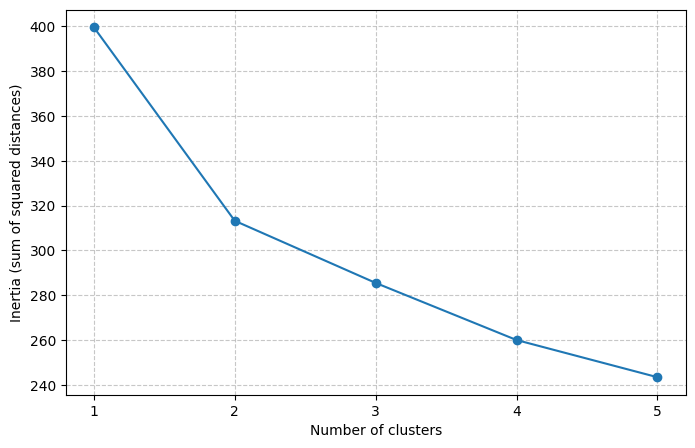

In [ ]:
# try to group emails into k clusters (we can pick the best k based on elbow method for example)
# model based solely on email text


# elbow method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np


max_k = 5
inertias = []
k_values = range(1, max_k + 1)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=7, n_init='auto')
    kmeans.fit(embeddings)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (sum of squared distances)')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

explained variance: 31.133142


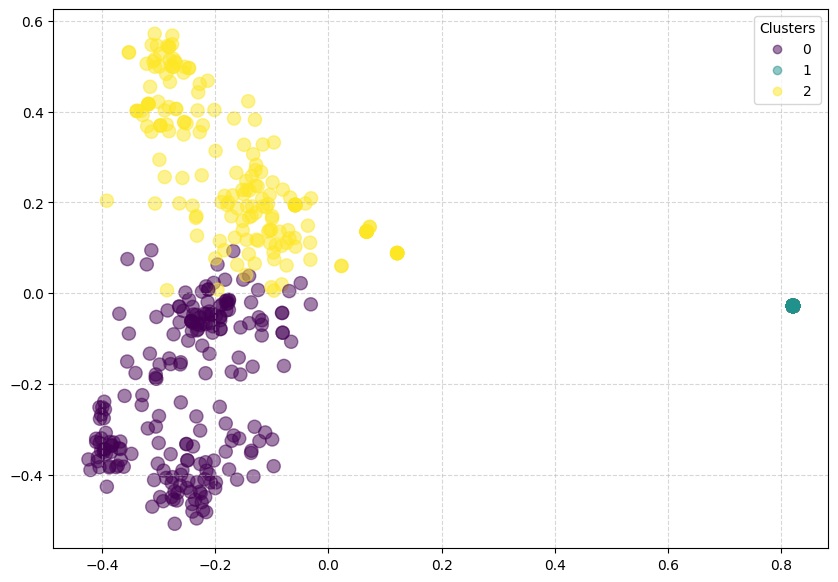

In [18]:
kmeans = KMeans(n_clusters=3, random_state=7, n_init='auto')
cluster_labels = kmeans.fit_predict(embeddings)

# we can use PCA for 2d visualization (even though it does not make much sense)
pca = PCA(n_components=2, random_state=7)
reduced_embeddings = pca.fit_transform(embeddings)
x_coords = reduced_embeddings[:, 0]
y_coords = reduced_embeddings[:, 1]

print("explained variance:", sum(pca.explained_variance_ratio_) * 100)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    x_coords, 
    y_coords, 
    c=cluster_labels,
    s=90,
    alpha=0.5,
)

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()